# Example of autoscaling problem

In [2]:
# Basic imports
%matplotlib widget
from numpy import mean
from ascal import AscalConfig, Ascal
from examples import aws_eu_west_1_c5m5r5

In [3]:
# Configuration file defining ASCAL problem
config_file = "config.yaml"
log_file = "config.log" # Log file

In [4]:
# Read the problem configuration file and validate it
# Note that it is possible to validate any ASCAL configuration with method AscalConfig.validate_config()
ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)

# Create the autoscaling problem
ascal_problem = Ascal(ascal_config, log=log_file)

# Last time that can be simulated (last time in the trace)
# Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
last_time = ascal_problem.last_time 
print(f'Time range of the simulation: 0 - {last_time} seconds')

# Run the autoscaling problem until the end. The argument of run() method is the last simulation time in seconds
# Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
ascal_problem.run()

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
You can check the CBC log at /tmp/9861edabcbac4d3487f2eb97276a1931-pulp.lp.log
You can check the CBC log at /tmp/99a91027c7664f01a064baead3e8ffdc-pulp.lp.log
You can check the CBC log at /tmp/75879899f3e34d1b96e2f646f74b3044-pulp.lp.log
You can check the CBC log at /tmp/a94944558a9a4c628e03da60098732c7-pulp.lp.log
You can check the CBC log at /tmp/230250f29920482ab3097eb6ed17578f-pulp.lp.log
You can check the CBC log at /tmp/9f263f3b43e44d13bb24f963455dc717-pulp.lp.log
Time: 100 s
Time: 200 s
Time: 300 s
You can check the CBC log at /tmp/1fd9d4d4745d4a94aa6b61cb0569cf13-pulp.lp.log
You can check the CBC log at /tmp/12b7d50f05fd473794c8e0dac81b3779-pulp.lp.log
You can check the CBC log at /tmp/405907f0532840adbc9bec1923d22e8e-pulp.lp.log
You can check the CBC log at /tmp/b4e4f233da54486c9c84c0a0c16dd716-pulp.lp.log
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/e5dcce5871c14e44a3ac94875bbe83a3-pulp.lp.log
Yo

In [5]:
# Write workloads, performance and cost into csv files. Each line in the csv files corresponds to 1 second
ascal_problem.write_workload_csv('workloads.csv')
ascal_problem.write_performance_csv('performances.csv')
ascal_problem.write_cost_csv('cost.csv')

In [6]:
# Write allocations in a YAML file
ascal_problem.write_allocations('allocations.yaml')

In [7]:
# Get application traffic intensity (workload/performance)
workloads = ascal_problem.get_workloads()
performances = ascal_problem.get_performances()
traffic_intensity = {app: [w/p for w, p in zip(workloads[app], performances[app])] for app in workloads}

In [8]:
# Get queue waiting times relative to service times, assuming each container is a server in a 
# heterogenous D/D/m queue
queue_waiting_times = ascal_problem.get_queue_waiting_times()
avgs = {
    app_name: mean(waiting_times)
    for app_name, waiting_times in queue_waiting_times.items()
}
for app_name in dict(queue_waiting_times):
    queue_waiting_times[f"{app_name} QoS = {avgs[app_name]:.3f}"] = queue_waiting_times.pop(app_name)

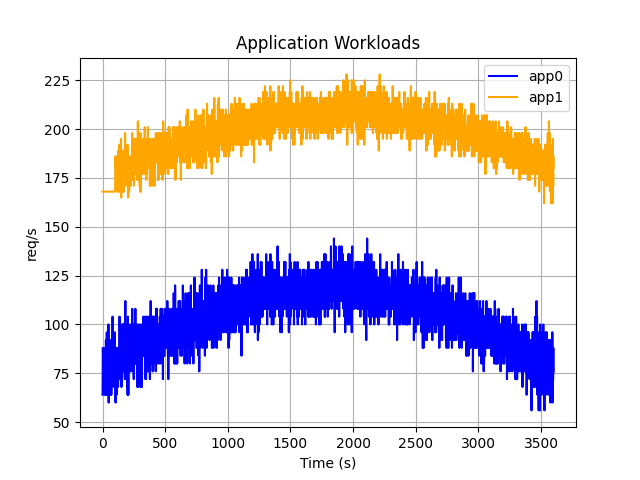

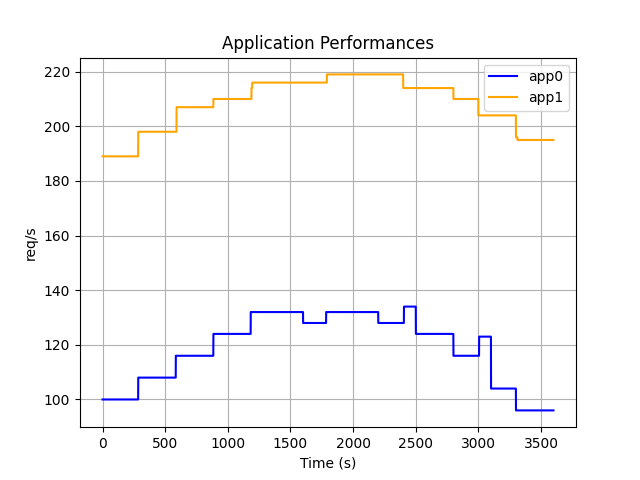

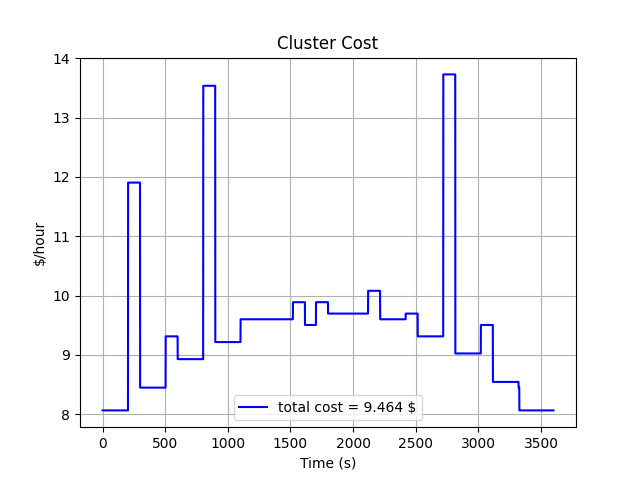

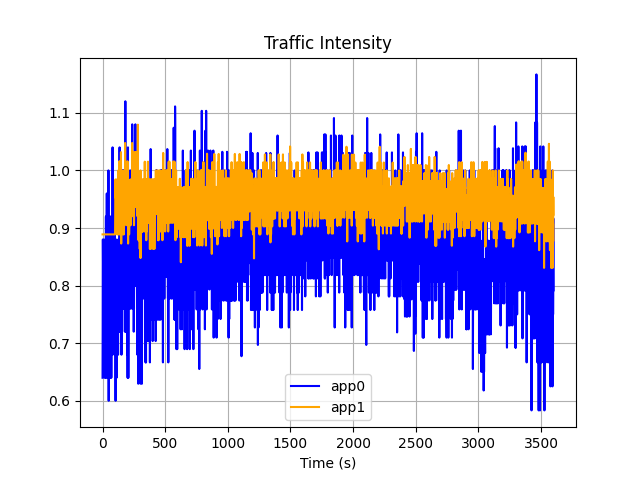

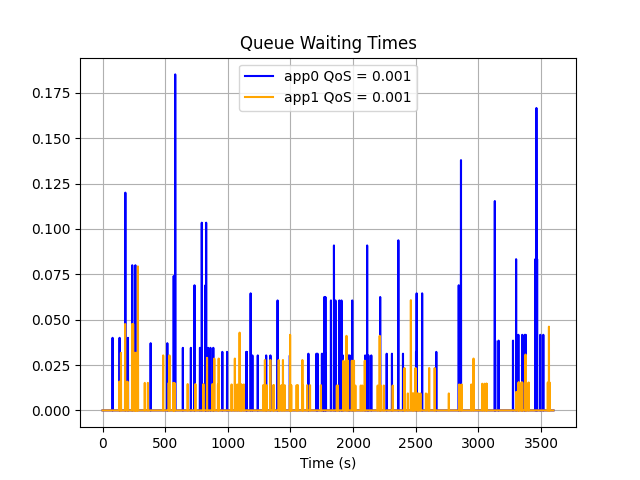

In [9]:
# Plot autoscaling information
ascal_problem.plot(ascal_problem.get_workloads(), "Application Workloads", "req/s")
ascal_problem.plot(ascal_problem.get_performances(), "Application Performances", "req/s")
cluster_cost = ascal_problem.get_cluster_cost()
total_cost_str = f"total cost = {sum(cluster_cost)/3600:.3f} $"
ascal_problem.plot({total_cost_str: cluster_cost}, "Cluster Cost", "$/hour")
ascal_problem.plot(traffic_intensity, "Traffic Intensity")
ascal_problem.plot(queue_waiting_times, "Queue Waiting Times")

In [10]:
# Useful properties
last_time = ascal_problem.last_time # Last time that can be simulated
current_time =  ascal_problem.time # Current simulated time in range [0, last_time]
billing_changes = ascal_problem.billing_changes # Dictionary with times and cluster state on billing changes
performance_changes = ascal_problem.performance_changes # Dictionary with times and cluster state on allocation changes
calculation_times = ascal_problem.calc_times # Calculation times to obtain new allocations

In [11]:
# Recycling levels for Horizontal/Vertical autoscalers
node_recycling_levels, container_recycling_levels = ascal_problem.get_recycling_levels()

/home/chechu/ascal/ascal/ascal.py:745: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


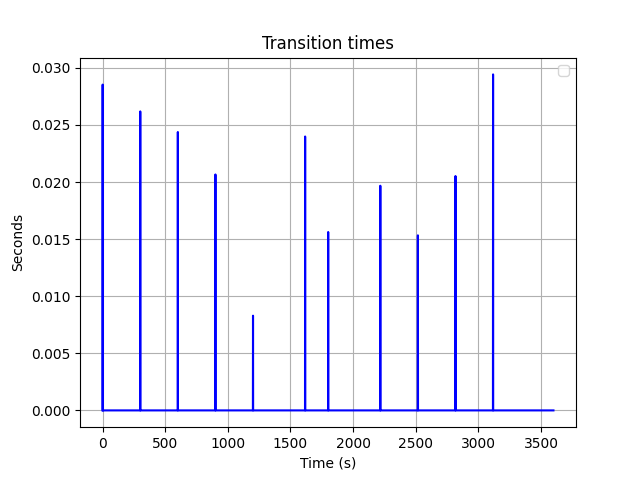

In [12]:
# Plot times to calculate transitions
transition_times = calculation_times["transition_times"]
ascal_problem.plot({'_nolegend_': transition_times}, "Transition times", "Seconds")

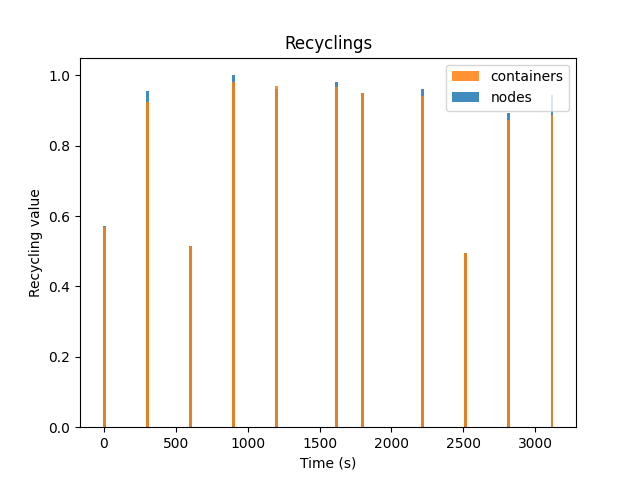

In [13]:
# Plot recyclings
ascal_problem.plot_bar({'nodes': node_recycling_levels, 'containers': container_recycling_levels},
                       "Recyclings", "Recycling value")